# Dark Matter Halo Two-Point Correlation Function (2PCF)

This notebook computes the two-point correlation function ξ(r) for **dark matter halos** using the Corrfunc library with periodic boundary conditions.

- **DM Halos**: Represented by central galaxies (is_central=1) from galaxies.hdf5
- **Subvolumes**: 1024 independent random realizations of the same 542³ Mpc³/h³ box
- **Periodic Box**: Corrfunc applies periodic boundary conditions with box size = 542 Mpc/h
- **Max Scale**: rmax < boxsize/2 ≈ 271 Mpc/h to avoid double-counting pairs

## Load Libraries

In [6]:
import sys
from pathlib import Path

_src = str(Path('../../src').resolve())
if _src not in sys.path:
    sys.path.insert(0, _src)

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from utils.matplotlib_config import register_matplotlib_setconfig
import importlib
from config import get_base_dir, set_base_dir
import analysis.correlation.dm_correlation as dm_corr

# Reload module to get latest fixes
dm_corr = importlib.reload(dm_corr)
dm_correlation_given_redshift_and_subvolume = dm_corr.dm_correlation_given_redshift_and_subvolume
avg_dm_correlation_given_subvolume_and_redshifts = dm_corr.avg_dm_correlation_given_subvolume_and_redshifts

# Set the correct base directory
set_base_dir('/cosma5/data/durham/dc-hick2/Galform_Out/L800/lc16')
base_dir = get_base_dir()
register_matplotlib_setconfig(mpl)
mpl.setconfig()

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

## Dark Matter Halo 2PCF from Merger Trees

In [7]:
# Compute DM correlation from galaxies.hdf5 (halo catalog)
example_snapshot = 'iz207'
example_ivol = 100
snap_path = str(base_dir / example_snapshot)

# Define bin edges
rbins = np.logspace(np.log10(0.1), np.log10(50.0), 20)

# Optional: apply minimum host halo mass cut (mhhalo is the host halo mass)
mhhalo_min = 1e11  # Msun (host halo mass)

dm_result = dm_correlation_given_redshift_and_subvolume(
    iz_path=snap_path,
    ivol=example_ivol,
    rbins=rbins,
    nthreads=4,
    mhhalo_min=mhhalo_min,
)

if dm_result is not None:
    z = dm_result.attrs.get('z')
    nhalo = dm_result.attrs.get('ngal')  # Actually number of halos
    boxsize = dm_result.attrs.get('boxsize')
    V_ivol = dm_result.attrs.get('V_ivol')
    
    z_str = f"{z:.4f}" if z is not None else "N/A"
    boxsize_str = f"{boxsize:.1f}" if boxsize is not None else "N/A"
    V_ivol_str = f"{V_ivol:.3e}" if V_ivol is not None else "N/A"
    
    print(f"Redshift: {z_str}")
    print(f"N_halos: {nhalo}")
    print(f"Boxsize: {boxsize_str} Mpc/h")
    print(f"V_ivol: {V_ivol_str} Mpc³/h³")
else:
    print(f"Failed to compute DM correlation for {example_snapshot}, ivol={example_ivol}")

Redshift: N/A
N_halos: 5410
Boxsize: 542.0 Mpc/h
V_ivol: 1.556e+05 Mpc³/h³



   r [Mpc/h]       ξ_DM(r)
--------------------------
        0.12  18693.137653
        0.23  21449.822477
        0.44   7872.204304
        0.85   1934.901484
        1.62    394.864464
        3.08     62.384259
        5.92      0.606168
       11.79      0.192376
       22.73     -0.008275
       43.74      0.020452


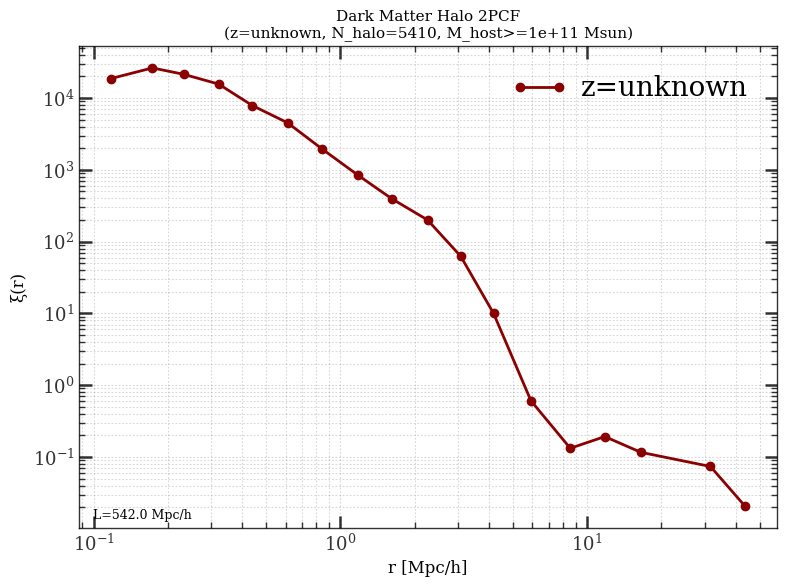

In [9]:
if dm_result is not None:
    r = dm_result['r'].to_numpy()
    xi_dm = dm_result['xi'].to_numpy()
    z = dm_result.attrs.get('z')
    nhalo = dm_result.attrs.get('ngal')
    boxsize = dm_result.attrs.get('boxsize')

    # Print data table
    print(f"\n{'r [Mpc/h]':>12}  {'ξ_DM(r)':>12}")
    print("-" * 26)
    for i in range(0, len(r), 2):
        if np.isfinite(xi_dm[i]):
            print(f"{r[i]:12.2f}  {xi_dm[i]:12.6f}")

    plt.figure(figsize=(8, 6))
    mask = (xi_dm > 0) & np.isfinite(xi_dm)
    z_str = f"{z:.2f}" if z is not None else "unknown"
    plt.loglog(r[mask], xi_dm[mask], 'o-', color='darkred', linewidth=2, markersize=6, label=f'z={z_str}')
    plt.xlabel('r [Mpc/h]', fontsize=12)
    plt.ylabel('ξ(r)', fontsize=12)
    title = "Dark Matter Halo 2PCF"
    title += f"\n(z={z_str}, N_halo={nhalo}, M_host>={mhhalo_min:.0e} Msun)"
    plt.title(title, fontsize=11)
    if boxsize is not None:
        plt.text(0.02, 0.02, f"L={boxsize:.1f} Mpc/h", transform=plt.gca().transAxes, fontsize=9)
    plt.legend()
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: dm_result is None")

In [ ]:
iz_nums = [155, 175, 207]
example_ivol = 100

results = []
for iz_num in iz_nums:
    iz_path = str(base_dir / f'iz{iz_num}')
    res = dm_correlation_given_redshift_and_subvolume(
        iz_path=iz_path,
        ivol=example_ivol,
        rbins=rbins,
        nthreads=4,
        mhhalo_min=mhhalo_min,
    )
    if res is not None:
        res.attrs['iz'] = f'iz{iz_num}'
        results.append(res)
        z = res.attrs.get('z')
        z_str = f"{z:.3f}" if z is not None else "N/A"
        print(f"iz{iz_num}: z={z_str} OK")
    else:
        print(f"iz{iz_num}: failed")

if results:
    plt.figure(figsize=(8, 6))
    for res in results:
        r_vals = res['r']
        xi_vals = res['xi']
        z_val = res.attrs.get('z')
        z_str = f"{z_val:.2f}" if z_val is not None else "unknown"
        mask = (xi_vals > 0) & np.isfinite(xi_vals)
        plt.loglog(r_vals[mask], xi_vals[mask], 'o-', markersize=4, label=f"z={z_str}")
    plt.xlabel('r [Mpc/h]', fontsize=12)
    plt.ylabel('ξ(r)', fontsize=12)
    plt.title(f'DM Halo 2PCF Evolution (ivol={example_ivol}, M_host>={mhhalo_min:.0e} Msun)', fontsize=11)
    plt.legend()
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()
else:
    print("No results to plot")